## Install & Import

In [1]:
!pip -q install datasets evaluate scikit-learn pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.7 MB/s eta 0:00:00


In [2]:
import os
import re
import ast
import json
import math
import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

dataset = load_dataset("jordiclive/FABSA")
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/747k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/105k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/158k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7930 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1057 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1587 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'org_index', 'data_source', 'industry', 'text', 'labels', 'label_codes'],
        num_rows: 7930
    })
    validation: Dataset({
        features: ['id', 'org_index', 'data_source', 'industry', 'text', 'labels', 'label_codes'],
        num_rows: 1057
    })
    test: Dataset({
        features: ['id', 'org_index', 'data_source', 'industry', 'text', 'labels', 'label_codes'],
        num_rows: 1587
    })
})

##Convert from HuggingFace to Pandas Dataframe

The FABSA dataset loaded from Hugging Face and converted into Pandas DataFrames. The dataset was split for the training, validation, and test.

The dataset consists of 7930 training samples, 1057 validation samples, and 1587 test samples, each containing review text along with associated aspect sentiment annotations.

In [3]:
def to_df(split):
    return pd.DataFrame(dataset[split])

train_df = to_df("train")
val_df = to_df("validation")
test_df = to_df("test")

print(train_df.shape, val_df.shape, test_df.shape)
train_df.head()

(7930, 7) (1057, 7) (1587, 7)


,id,org_index,data_source,industry,text,labels,label_codes
0,301972057,600,Trustpilot,Price Comparison,My experience is only around the Parking forum...,"[[Staff support: Attitude of staff, negative],...","['staff-support.attitude-of-staff.-1', 'compan..."
1,301982453,514,Google Play,Banking,"I love it so handy, plus I hate my bank so it ...","[[Company brand: General satisfaction, positiv...","['company-brand.general-satisfaction.1', 'comp..."
2,301980653,369,Google Play,Ride Hailing,Sometimes it takes,"[[Company brand: General satisfaction, negative]]",['company-brand.general-satisfaction.-1']
3,301979991,727,Apple Store,Fashion,This is the worst app I ordered my sneakers 2/...,"[[Logistics rides: Speed, negative], [Online e...","['logistics-rides.speed.-1', 'online-experienc..."
4,301984330,549,Google Play,Travel Booking,So easy & loads of info !,"[[Company brand: General satisfaction, positive]]",['company-brand.general-satisfaction.1']


##Schema normalization + label space extraction

Normalising the labels and created a new column called "labels_parsed"

In [4]:
def normalize_labels_cell(x):
    '''
    FABSA labels are typically stored like:
    [["Company brand: General satisfaction", "positive"], ...]
    This function converts the field safely to a Python list.
    '''
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return []

for df in [train_df, val_df, test_df]:
    df["labels_parsed"] = df["labels"].apply(normalize_labels_cell)

all_aspects = sorted({
    aspect for df in [train_df, val_df, test_df]
    for labels in df["labels_parsed"]
    for aspect, sent in labels
})

all_sentiments = sorted({
    sent for df in [train_df, val_df, test_df]
    for labels in df["labels_parsed"]
    for aspect, sent in labels
})

print("Number of aspects:", len(all_aspects))
print("Aspects:", all_aspects)
print("Sentiments:", all_sentiments)

Number of aspects: 12
Aspects: ['Account management: Account access', 'Company brand: Competitor', 'Company brand: General satisfaction', 'Company brand: Reviews', 'Logistics rides: Speed', 'Online experience: App website', 'Purchase booking experience: Ease of use', 'Staff support: Attitude of staff', 'Staff support: Email', 'Staff support: Phone', 'Value: Discounts promotions', 'Value: Price value for money']
Sentiments: ['negative', 'neutral', 'positive']


##Exploratory Data Analysis

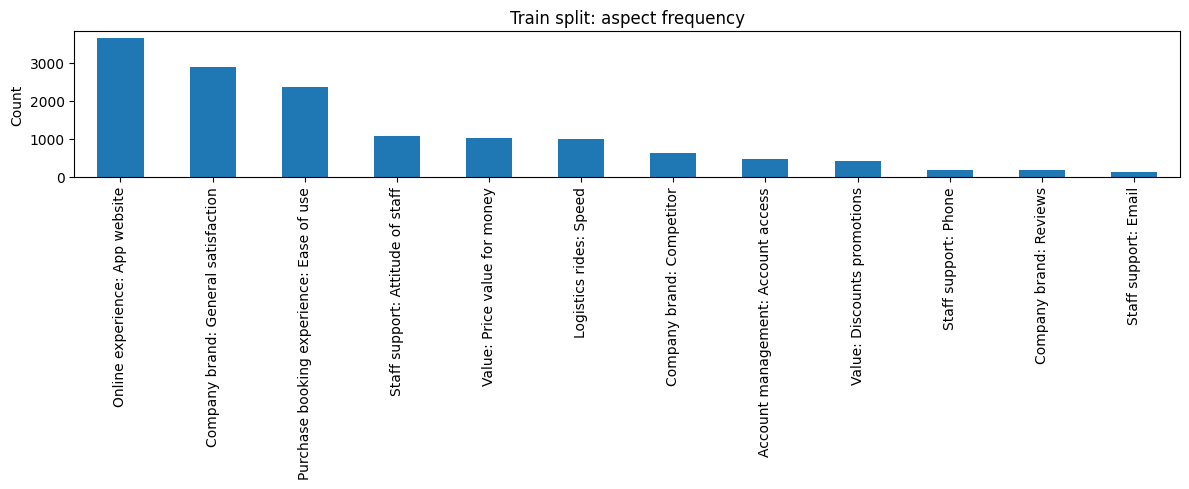

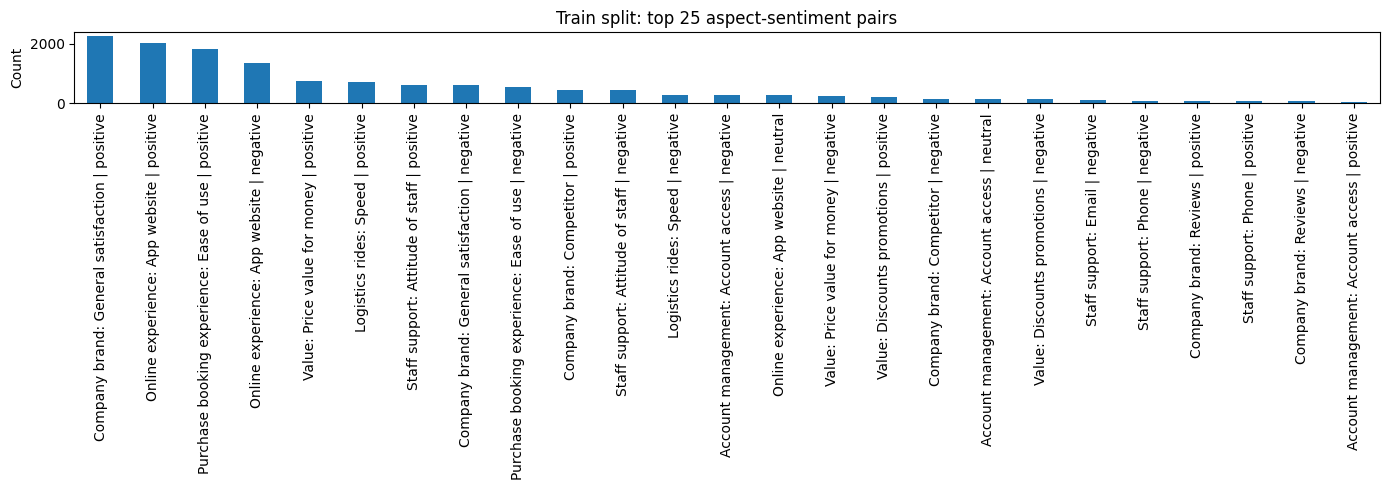

In [5]:
aspect_counter = Counter()
pair_counter = Counter()

for labels in train_df["labels_parsed"]:
    for aspect, sent in labels:
        aspect_counter[aspect] += 1
        pair_counter[(aspect, sent)] += 1

aspect_series = pd.Series(aspect_counter).sort_values(ascending=False)
pair_series = pd.Series({f"{a} | {s}": c for (a, s), c in pair_counter.items()}).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
aspect_series.plot(kind="bar")
plt.title("Train split: aspect frequency")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
pair_series.head(25).plot(kind="bar")
plt.title("Train split: top 25 aspect-sentiment pairs")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

##Aspect Category Detection

Frequency distributions were computed. Possible class imbalances found

In [6]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score, classification_report, accuracy_score, precision_recall_fscore_support

def get_acd_targets(df):
    return [[aspect for aspect, sent in labels] for labels in df["labels_parsed"]]

mlb = MultiLabelBinarizer(classes=all_aspects)
Y_train_acd = mlb.fit_transform(get_acd_targets(train_df))
Y_val_acd = mlb.transform(get_acd_targets(val_df))
Y_test_acd = mlb.transform(get_acd_targets(test_df))

acd_model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=50000, sublinear_tf=True)),
    ("clf", OneVsRestClassifier(
        LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear")
    ))
])

acd_model.fit(train_df["text"], Y_train_acd)

val_probs = np.column_stack([est.predict_proba(acd_model.named_steps["tfidf"].transform(val_df["text"]))[:, 1]
                             for est in acd_model.named_steps["clf"].estimators_])
test_probs = np.column_stack([est.predict_proba(acd_model.named_steps["tfidf"].transform(test_df["text"]))[:, 1]
                              for est in acd_model.named_steps["clf"].estimators_])

def threshold_search(y_true, probs, grid=np.arange(0.2, 0.81, 0.05)):
    best_t, best_f1 = 0.5, -1
    for t in grid:
        preds = (probs >= t).astype(int)
        score = f1_score(y_true, preds, average="micro", zero_division=0)
        if score > best_f1:
            best_t, best_f1 = t, score
    return best_t, best_f1

best_t, best_val_f1 = threshold_search(Y_val_acd, val_probs)
test_preds_acd = (test_probs >= best_t).astype(int)

print("Best validation threshold:", best_t)
print("Validation micro-F1:", best_val_f1)
print("Test micro-F1:", f1_score(Y_test_acd, test_preds_acd, average="micro", zero_division=0))
print("Test macro-F1:", f1_score(Y_test_acd, test_preds_acd, average="macro", zero_division=0))
print("Test subset accuracy:", accuracy_score(Y_test_acd, test_preds_acd))

Best validation threshold: 0.5499999999999999
Validation micro-F1: 0.7564454196379594
Test micro-F1: 0.7560399636693914
Test macro-F1: 0.7045317272574708
Test subset accuracy: 0.4612476370510397


##Per Aspect Performance Evaluation

Precision, recall, and F1-score were calculated for every aspect

In [7]:
# Per-aspect ACD breakdown
acd_report = classification_report(
    Y_test_acd,
    test_preds_acd,
    target_names=mlb.classes_,
    zero_division=0,
    output_dict=True
)
acd_report_df = pd.DataFrame(acd_report).T
acd_report_df.sort_values("f1-score", ascending=False).head(20)

,precision,recall,f1-score,support
Online experience: App website,0.936688,0.796961,0.861194,724.0
Logistics rides: Speed,0.750000,0.777778,0.763636,189.0
Purchase booking experience: Ease of use,0.793103,0.731610,0.761117,503.0
weighted avg,0.779066,0.745611,0.759117,2791.0
micro avg,0.766765,0.745611,0.756040,2791.0
samples avg,0.765448,0.760999,0.738299,2791.0
Value: Price value for money,0.718894,0.757282,0.737589,206.0
Staff support: Attitude of staff,0.694690,0.781095,0.735363,201.0
Company brand: General satisfaction,0.725136,0.691379,0.707855,580.0
Account management: Account access,0.659341,0.759494,0.705882,79.0


##format for Aspect Sentiment Classification

Converting to aspect–sentiment pair for supervised learning

In [8]:
# Build ACSC pair-level dataset
def build_pair_df(df):
    rows = []
    for _, row in df.iterrows():
        text = row["text"]
        labels = row["labels_parsed"]
        for aspect, sent in labels:
            rows.append({
                "text": text,
                "aspect": aspect,
                "sentiment": sent,
                "pair_text": f"{text} [ASPECT] {aspect}"
            })
    return pd.DataFrame(rows)

train_pair_df = build_pair_df(train_df)
val_pair_df = build_pair_df(val_df)
test_pair_df = build_pair_df(test_df)

print(train_pair_df.shape, val_pair_df.shape, test_pair_df.shape)
train_pair_df.head()

(13998, 4) (1858, 4) (2812, 4)


,text,aspect,sentiment,pair_text
0,My experience is only around the Parking forum...,Staff support: Attitude of staff,negative,My experience is only around the Parking forum...
1,My experience is only around the Parking forum...,Company brand: Reviews,negative,My experience is only around the Parking forum...
2,My experience is only around the Parking forum...,Company brand: General satisfaction,negative,My experience is only around the Parking forum...
3,"I love it so handy, plus I hate my bank so it ...",Company brand: General satisfaction,positive,"I love it so handy, plus I hate my bank so it ..."
4,"I love it so handy, plus I hate my bank so it ...",Company brand: Competitor,positive,"I love it so handy, plus I hate my bank so it ..."


##Sentiment Classifier for ACSC

A TF-IDF and Logistic Regression was used to classify sentiment for each review aspect pair in the ACSC task

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

acsc_model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=70000, sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

acsc_model.fit(train_pair_df["pair_text"], train_pair_df["sentiment"])

val_pred_sent = acsc_model.predict(val_pair_df["pair_text"])
test_pred_sent = acsc_model.predict(test_pair_df["pair_text"])

print("Validation macro-F1:", f1_score(val_pair_df["sentiment"], val_pred_sent, average="macro"))
print("Test accuracy:", accuracy_score(test_pair_df["sentiment"], test_pred_sent))
print("Test micro-F1:", f1_score(test_pair_df["sentiment"], test_pred_sent, average="micro"))
print("Test macro-F1:", f1_score(test_pair_df["sentiment"], test_pred_sent, average="macro"))
print(classification_report(test_pair_df["sentiment"], test_pred_sent, digits=4))

Validation macro-F1: 0.816690918420807
Test accuracy: 0.8886913229018493
Test micro-F1: 0.8886913229018493
Test macro-F1: 0.8238670731275537
              precision    recall  f1-score   support

    negative     0.8080    0.8828    0.8437       896
     neutral     0.6148    0.8242    0.7042        91
    positive     0.9544    0.8948    0.9236      1825

    accuracy                         0.8887      2812
   macro avg     0.7924    0.8673    0.8239      2812
weighted avg     0.8968    0.8887    0.8911      2812



##Evaluation

Model performance was evaluated at both the ACSC and end-to-end ABSA levels.

A confusion matrix was used to analyse sentiment misclassification patterns.

Final end-to-end precision, recall, and F1-score were then computed by comparing predicted aspect sentiment pairs against the standard annotations.

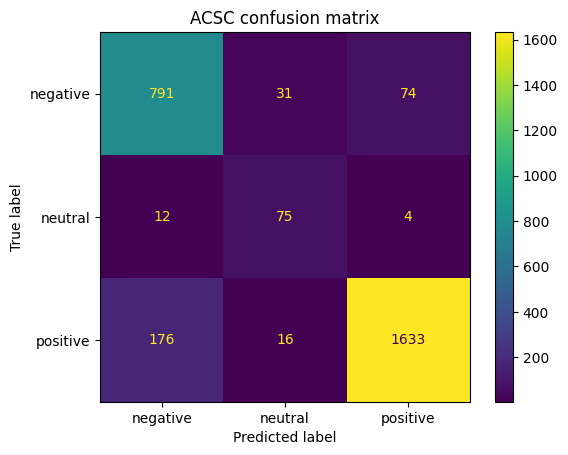

In [10]:
cm = confusion_matrix(test_pair_df["sentiment"], test_pred_sent, labels=sorted(all_sentiments))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(all_sentiments))
disp.plot()
plt.title("ACSC confusion matrix")
plt.show()

In [11]:
def predict_aspects_for_texts(texts, threshold=best_t):
    tfidf = acd_model.named_steps["tfidf"].transform(texts)
    probs = np.column_stack([est.predict_proba(tfidf)[:, 1] for est in acd_model.named_steps["clf"].estimators_])
    preds = (probs >= threshold).astype(int)
    aspect_lists = []
    for row in preds:
        labels = [mlb.classes_[i] for i, v in enumerate(row) if v == 1]
        if not labels:
            # fallback: choose highest-probability aspect
            top_idx = int(np.argmax(probs[len(aspect_lists)]))
            labels = [mlb.classes_[top_idx]]
        aspect_lists.append(labels)
    return aspect_lists

def predict_sentiment(text, aspect):
    return acsc_model.predict([f"{text} [ASPECT] {aspect}"])[0]

gold_pairs = []
pred_pairs = []

predicted_aspects = predict_aspects_for_texts(test_df["text"].tolist())

for row, pred_aspects in zip(test_df.itertuples(index=False), predicted_aspects):
    gold = {(a, s) for a, s in row.labels_parsed}
    pred = {(a, predict_sentiment(row.text, a)) for a in pred_aspects}
    gold_pairs.append(gold)
    pred_pairs.append(pred)

def multilabel_pair_f1(gold_sets, pred_sets):
    tp = fp = fn = 0
    for gold, pred in zip(gold_sets, pred_sets):
        tp += len(gold & pred)
        fp += len(pred - gold)
        fn += len(gold - pred)
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    return {"precision": precision, "recall": recall, "f1": f1}

end_to_end = multilabel_pair_f1(gold_pairs, pred_pairs)
end_to_end

{'precision': 0.6842480399142251,
 'recall': 0.682788051208861,
 'f1': 0.6835172654306934}